# Predicting future values
here time is split into trainin and testing. Prediction is done and evaluated. 
we will predict 3 month revenue for a customer using RFM + behaviour

In [89]:
import pandas as pd

In [90]:
rfm = pd.read_csv("data/rfm_features.csv")
df = pd.read_csv("data/cleaned_data.csv")

In [91]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [92]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [93]:
cuttof = df["InvoiceDate"].max() - pd.DateOffset(months=3)

In [94]:
cuttof

Timestamp('2011-09-09 12:50:00')

In [95]:
train_df = df[df["InvoiceDate"] <= cuttof]
future_df = df[df["InvoiceDate"] > cuttof]

how we are going to make the dataset:  
from the train data -> extracting features (x)  
from the future data (test data) -> taking target(y)  

by this we can input to the model

# building rfm on train data

cuttoff = last date of training window  
Everything after that is “future”  
so taking the data just before the cuttoff date (why - because, we want to predict the future right, if not done, first day recency will be 0) -> we are adding another day to cuttoffday

In [96]:
snapshot_train_data = cuttof + pd.Timedelta(days=1)

In [97]:
snapshot_train_data

Timestamp('2011-09-10 12:50:00')

In [98]:
# diving the trainig data to recency, frequency, monetory

In [99]:
rfm_train = train_df.groupby("CustomerID").agg({
    "InvoiceDate" : lambda x: (snapshot_train_data - x.max()).days, # recency
    "InvoiceNo": "nunique", # frequency
    "Revenue" : "sum" #monetory
    
})

In [100]:
rfm_train.columns = ["Recency", "Frequency", "Monetary"]

In [101]:
rfm_train.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,235,1,77183.60
12347.0,39,5,2790.86
12348.0,158,3,1487.24
12350.0,219,1,334.40
12352.0,171,5,1561.81


In [102]:
# target column of future data

In [103]:
future_revenue = future_df.groupby("CustomerID")["Revenue"].sum().reset_index()

In [104]:
future_revenue.head(2)

,CustomerID,Revenue
0,12347.0,1519.14
1,12348.0,310.00


In [105]:
future_revenue.columns  =["CustomerID", "clv"]

In [106]:
data_merged = rfm_train.merge(future_revenue, on= "CustomerID", how = "left")
data_merged.head()

,CustomerID,Recency,Frequency,Monetary,clv
0,12346.0,235,1,77183.60,NaN
1,12347.0,39,5,2790.86,1519.14
2,12348.0,158,3,1487.24,310.00
3,12350.0,219,1,334.40,NaN
4,12352.0,171,5,1561.81,944.23


here containing Nan values - people who do not purchased with in last 3 months is not in the list of future df. so after merging they are not in the list

In [107]:
data_merged["clv"] = data_merged["clv"].fillna(0)

In [108]:
data_merged.shape

(3365, 5)

In [109]:
# data_merged.dropna(subset=["clv"] ,inplace = True)

In [110]:
data_merged.head()

,CustomerID,Recency,Frequency,Monetary,clv
0,12346.0,235,1,77183.60,0.00
1,12347.0,39,5,2790.86,1519.14
2,12348.0,158,3,1487.24,310.00
3,12350.0,219,1,334.40,0.00
4,12352.0,171,5,1561.81,944.23


In [111]:
data_merged.shape

(3365, 5)

# training clv model

In [112]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error

In [113]:
x = data_merged.drop(columns=["clv","CustomerID"])
y = data_merged["clv"]

In [114]:
print(x.head(2),end="\n\n")
print(y.head(2))

   Recency  Frequency  Monetary
0      235          1  77183.60
1       39          5   2790.86

0       0.00
1    1519.14
Name: clv, dtype: float64


In [115]:
x_train,x_test, y_train, y_test = train_test_split(x,y, random_state=42)

In [116]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [117]:
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [118]:
y_pred = model.predict(x_test)

In [119]:
r2score = r2_score(y_pred, y_test)
rmse = root_mean_squared_error(y_pred,y_test)

In [120]:
print(f"r2score {r2score:.4f}")
print("rmse ",rmse)

r2score -0.0146
rmse  5609.350102924434


In [121]:
#

# feature importance

In [94]:
# fi = model.feature_importances_
# fi
# array([0.0271568 , 0.02502621, 0.07237632, 0.87544068])

In [95]:
fi = pd.Series(model.feature_importances_, index = x.columns)

In [96]:
import matplotlib.pyplot as plt

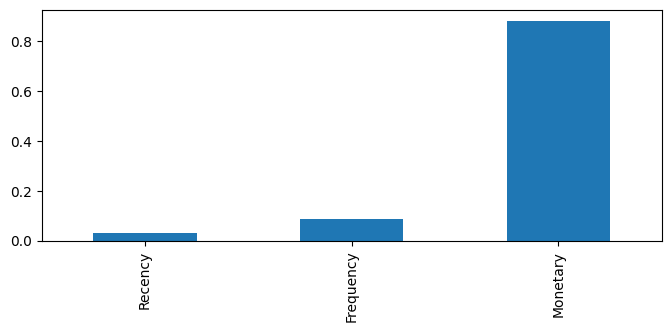

In [97]:
plt.figure(figsize=(8,3))
fi.plot(kind="bar")
plt.show()

In [98]:
import joblib

In [99]:
import os
os.makedirs("models", exist_ok=True)

In [100]:
joblib.dump(model,"models/clv_model.joblib")

['models/clv_model.joblib']

In [101]:
# type(model)

In [ ]:
# model.predict([[326,1,77183.6]])

/home/math/miniforge3/envs/super/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([17942.2533])